# Processing of pose estimation data

Convert SLEAP output files (`.slp`) into movement package `xarray` format and extract stable multi-camera correspondences.

### Pipeline Overview

1. **`ingest_pose_data()`**  
   Processes SLEAP output files (`.slp`) into movement package `xarray` format.  
   - **Output:** `*_pose_data.nc`  
   - **Location:** `/processed` folder  

2. **`extract_stable_events()`**  
   Identifies time periods where the card is flat on the table and not moving.  
   - **Output:** `*_stable_events.nc` (xarray format)  

3. **`match_stable_correspondences()`**  
   Matches frames across cameras that occur simultaneously during stable periods.  
   - **Outputs:**  
     - DataFrame of matched frames across cameras  
     - `stable_correspondences_minOverlap0.5s.csv`

## Load .slp data to xarrays from the movement package

In [2]:
import sys
from pathlib import Path
import importlib
import scripts.process_pose_data  # import the module itself, not just its contents

sys.path.append(str(Path().resolve().parent))

import scripts.process_pose_data as pp
importlib.reload(pp)

<module 'scripts.process_pose_data' from '/Users/zosiasus/Documents/Aeon3_SLEAP/AEON_sleap_analysis/scripts/process_pose_data.py'>

In [3]:
predictions_path = Path("/Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/predictions/")
cameras = ["CameraEast", "CameraNorth", "CameraSouth", "CameraWest", "CameraNest", "CameraTop"]

In [7]:
# Run once to ingest
out_dir = pp.ingest_pose_data(
    cameras=cameras,
    pred_path=predictions_path,
    fps=50.0,                        # optional, defaults to 50
)

Ingesting CameraEast: CameraEast_CameraEast_2026-04-14T14-00-00.slp


2026-04-28 11:55:07.060 | WARNING  | movement.io.load_poses:_ds_from_sleap_labels_file:583 - Could not find SLEAP Track in /Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/predictions/CameraEast_CameraEast_2026-04-14T14-00-00.slp. Assuming single-individual dataset and assigning default individual name.


  Skipping CameraEast: already ingested
Ingesting CameraNorth: CameraNorth_CameraNorth_2026-04-14T14-00-00.slp


2026-04-28 11:55:09.412 | WARNING  | movement.io.load_poses:_ds_from_sleap_labels_file:583 - Could not find SLEAP Track in /Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/predictions/CameraNorth_CameraNorth_2026-04-14T14-00-00.slp. Assuming single-individual dataset and assigning default individual name.


  Skipping CameraNorth: already ingested
Ingesting CameraSouth: CameraSouth_CameraSouth_2026-04-14T14-00-00.slp


...

  Skipping CameraWest: already ingested
Ingesting CameraNest: CameraNest_CameraNest_2026-04-14T14-00-00.slp


2026-04-28 11:55:15.611 | WARNING  | movement.io.load_poses:_ds_from_sleap_labels_file:583 - Could not find SLEAP Track in /Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/predictions/CameraNest_CameraNest_2026-04-14T14-00-00.slp. Assuming single-individual dataset and assigning default individual name.


  Skipping CameraNest: already ingested
Ingesting CameraTop: CameraTop_CameraTop_2026-04-14T14-00-00.slp


2026-04-28 11:55:18.243 | WARNING  | movement.io.load_poses:_ds_from_sleap_labels_file:583 - Could not find SLEAP Track in /Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/predictions/CameraTop_CameraTop_2026-04-14T14-00-00.slp. Assuming single-individual dataset and assigning default individual name.


  Skipping CameraTop: already ingested


In [8]:
print(out_dir)

/Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/processed


## Find and extract stable points

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

sys.path.append(str(Path().resolve().parent))

import scripts.extract_stable_events as ese
importlib.reload(ese)

<module 'scripts.extract_stable_events' from '/Users/zosiasus/Documents/Aeon3_SLEAP/AEON_sleap_analysis/scripts/extract_stable_events.py'>

In [10]:
processed_path = out_dir
cam = "CameraEast"

ds = xr.open_dataset(processed_path / f"{cam}_pose_data.nc")
print(ds)

<xarray.Dataset> Size: 2MB
Dimensions:      (time: 29584, space: 2, keypoints: 4, individuals: 1)
Coordinates:
  * time         (time) float64 237kB 0.0 0.02 0.04 0.06 ... 591.6 591.6 591.7
  * space        (space) <U1 8B 'x' 'y'
  * keypoints    (keypoints) <U8 128B 'corner_1' 'corner_2' ... 'corner_4'
  * individuals  (individuals) <U4 16B 'id_0'
Data variables:
    position     (time, space, keypoints, individuals) float32 947kB ...
    confidence   (time, keypoints, individuals) float32 473kB ...
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    fps:              50.0
    time_unit:        seconds
    source_file:      /Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/pre...



Processing: CameraEast
  Confidence distribution (valid n=39872):
    Q1=0.5654  Q2=0.8690  Q3=0.9731  max=1.1756
  Inferred confidence threshold (Q1): 0.5654
  Valid frames (all corners + confidence): 5172/29584
  Median card area (valid frames): 2440.5 px²
  Geometry-passing frames: 5171/5172
  Inferred pixel tolerance (P10 of displacements): 2.071 px
  Stable windows found: 42


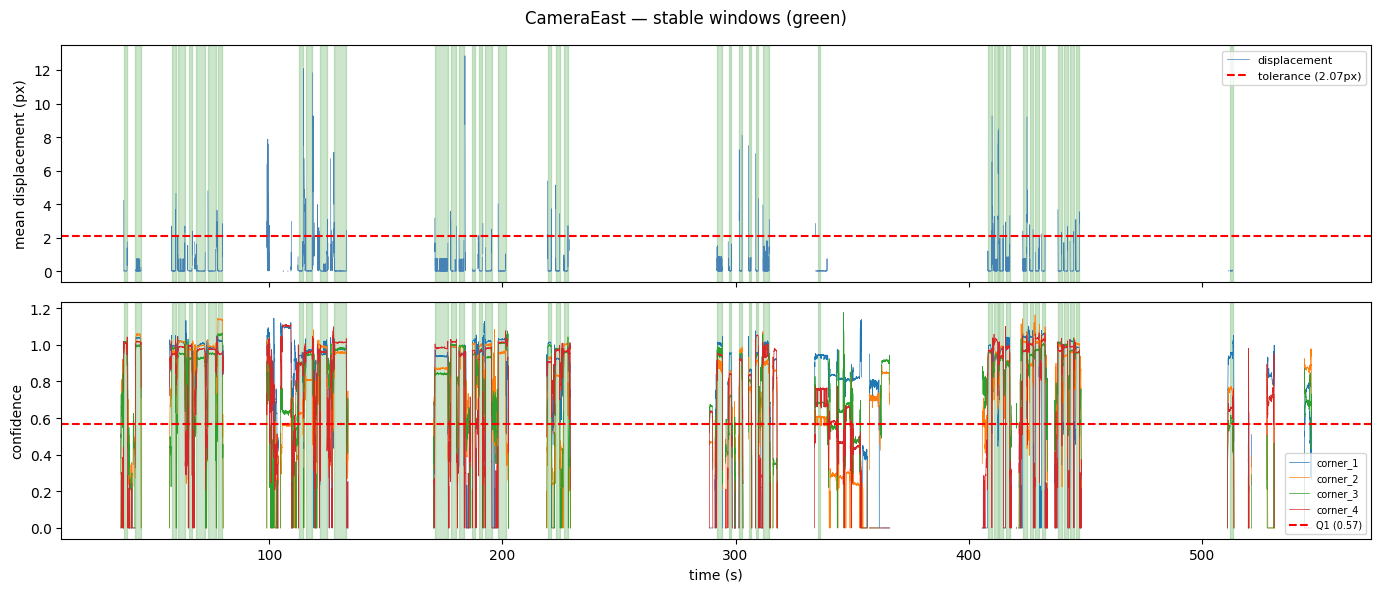

  Saved: /Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/processed/CameraEast_stable_events.nc

Processing: CameraNorth
  Confidence distribution (valid n=38784):
    Q1=0.6549  Q2=0.9115  Q3=0.9710  max=1.2334
  Inferred confidence threshold (Q1): 0.6549
  Valid frames (all corners + confidence): 5469/29584
  Median card area (valid frames): 2332.1 px²
  Geometry-passing frames: 5469/5469
  Inferred pixel tolerance (P10 of displacements): 1.686 px
  Stable windows found: 46


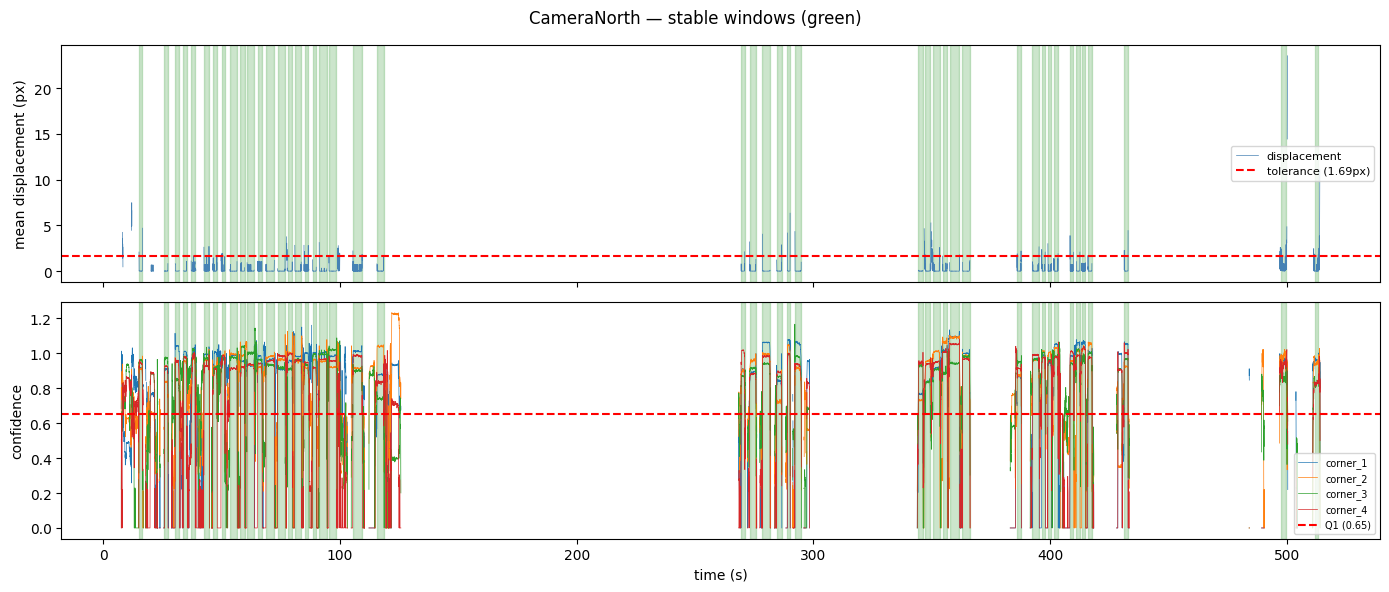

  Saved: /Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/processed/CameraNorth_stable_events.nc

Processing: CameraSouth
  Confidence distribution (valid n=42120):
    Q1=0.4526  Q2=0.6741  Q3=0.8336  max=1.1820
  Inferred confidence threshold (Q1): 0.4526
  Valid frames (all corners + confidence): 5050/29584
  Median card area (valid frames): 2907.5 px²
  Geometry-passing frames: 5018/5050
  Inferred pixel tolerance (P10 of displacements): 3.484 px
  Stable windows found: 39


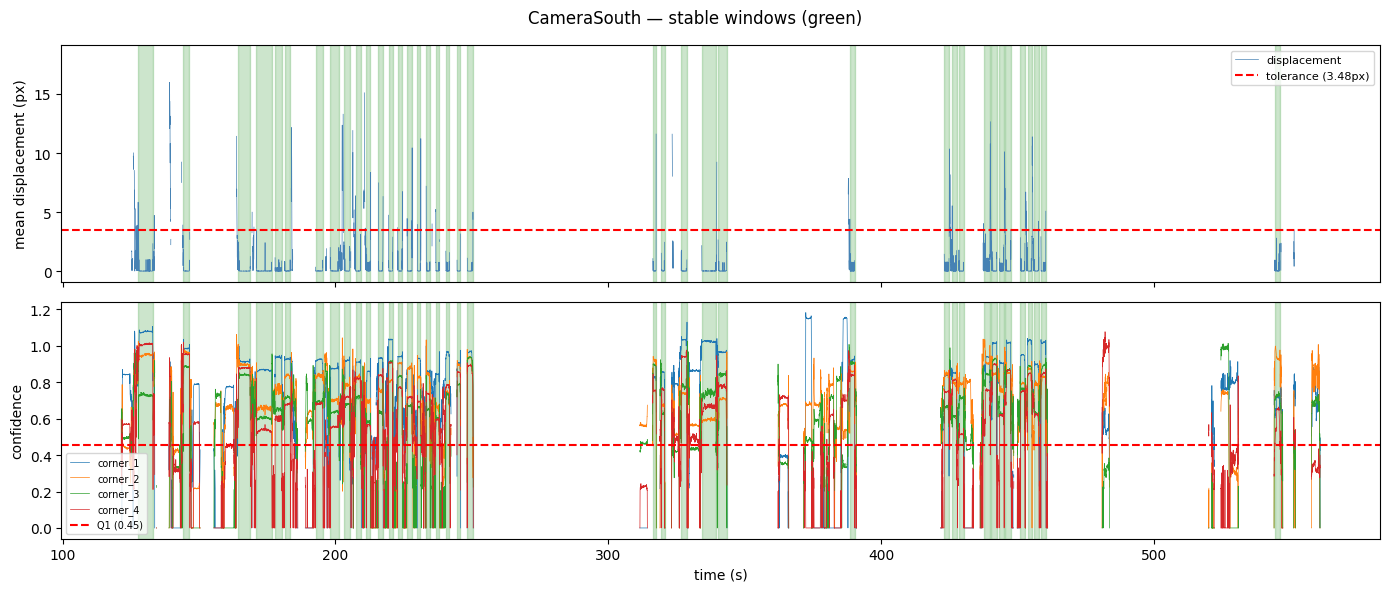

  Saved: /Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/processed/CameraSouth_stable_events.nc

Processing: CameraWest
  Confidence distribution (valid n=41040):
    Q1=0.5162  Q2=0.7519  Q3=0.8964  max=1.2576
  Inferred confidence threshold (Q1): 0.5162
  Valid frames (all corners + confidence): 5326/29584
  Median card area (valid frames): 2457.6 px²
  Geometry-passing frames: 5326/5326
  Inferred pixel tolerance (P10 of displacements): 2.823 px
  Stable windows found: 43


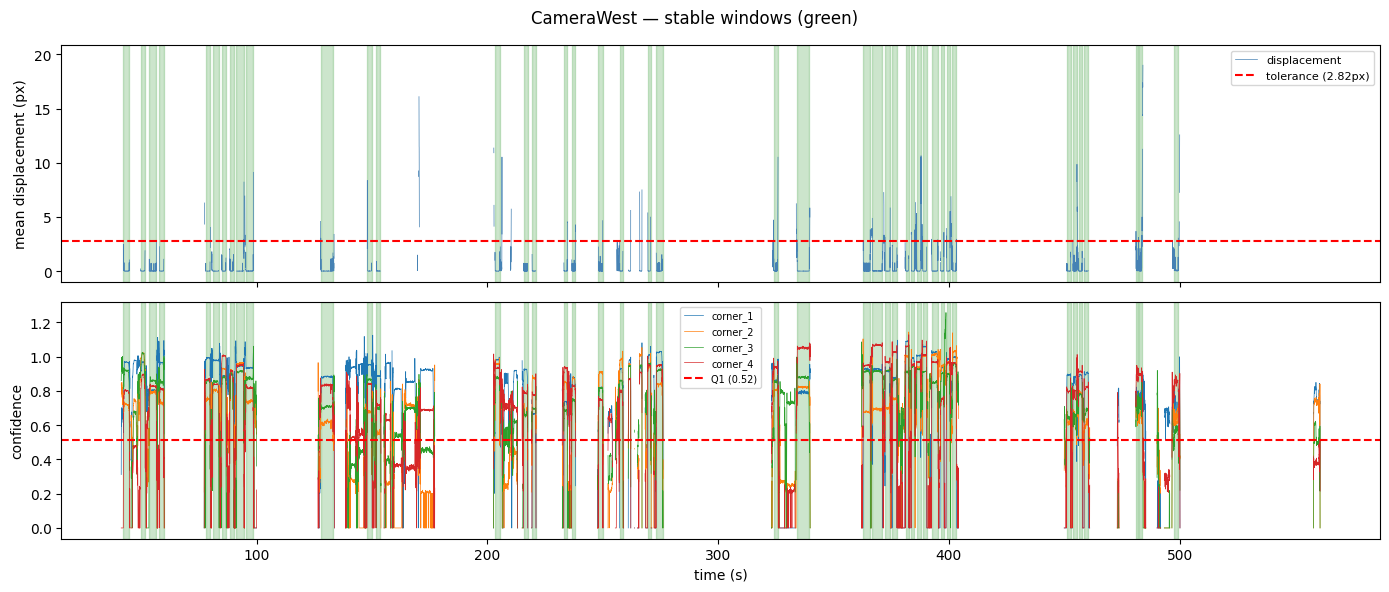

  Saved: /Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/processed/CameraWest_stable_events.nc

Processing: CameraTop
  Confidence distribution (valid n=78876):
    Q1=0.8035  Q2=0.9417  Q3=0.9956  max=1.2422
  Inferred confidence threshold (Q1): 0.8035
  Valid frames (all corners + confidence): 10615/29584
  Median card area (valid frames): 862.9 px²
  Geometry-passing frames: 10615/10615
  Inferred pixel tolerance (P10 of displacements): 1.114 px
  Stable windows found: 84


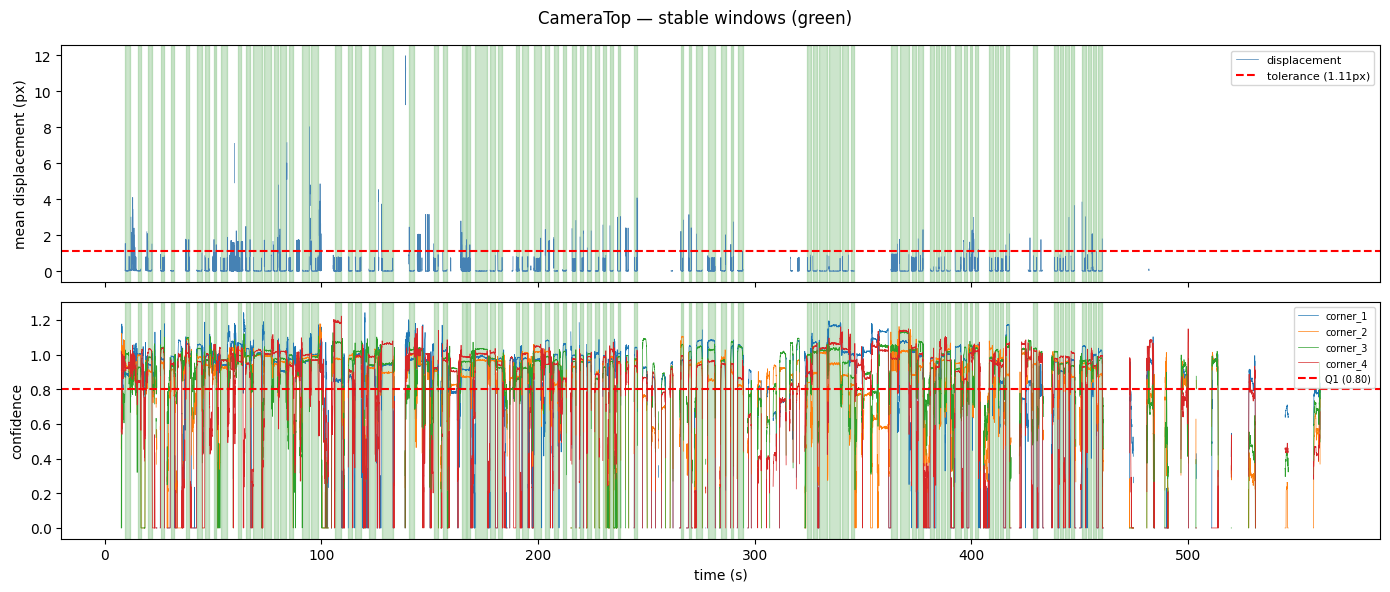

  Saved: /Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/processed/CameraTop_stable_events.nc

Processing: CameraNest
  Valid frames (all corners + confidence): 298/29584
  Median card area (valid frames): 12311.6 px²
  Geometry-passing frames: 298/298
  Stable windows found: 5


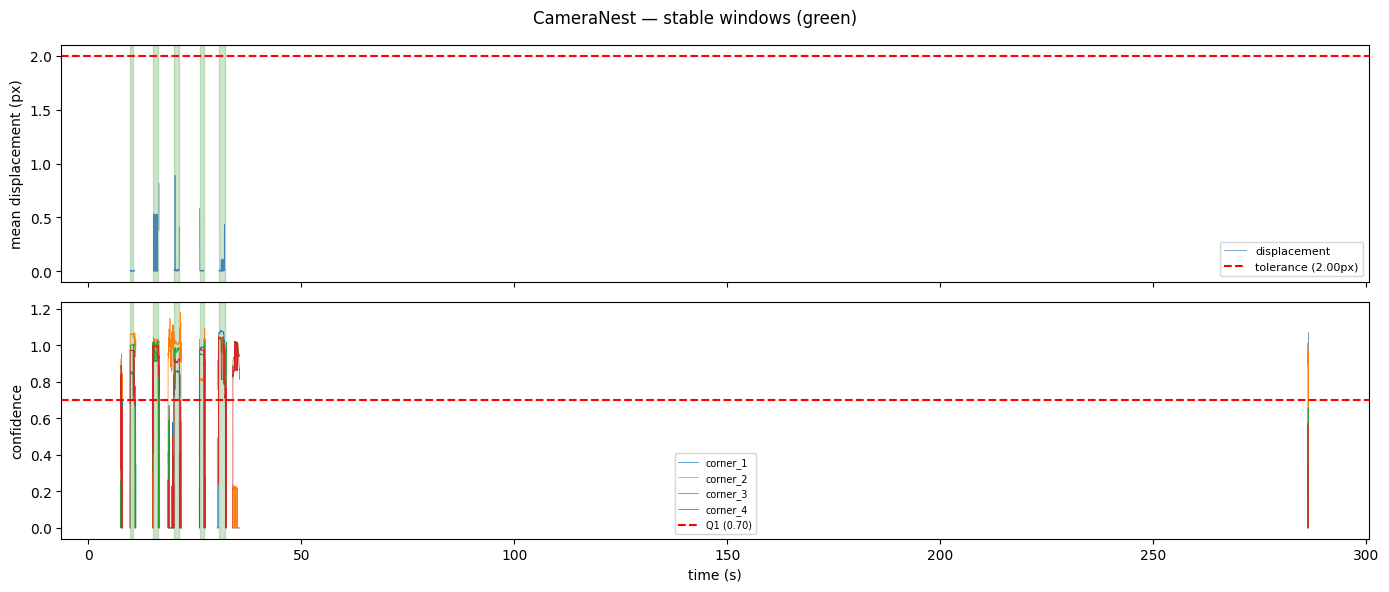

  Saved: /Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/processed/CameraNest_stable_events.nc


In [ ]:
# Standard cameras
out_dir = ese.extract_stable_events(
    cameras=["CameraEast", "CameraNorth", "CameraSouth", "CameraWest", "CameraTop"],
    processed_path=processed_path,
    min_duration_s=1.0,
    pixel_tolerance=None,
    min_confidence=None,
    fps=50.0,
    visual=True,
)

# CameraNest — adjusted params as Nest camera has closer view and shorter card placement windows
out_dir_nest = ese.extract_stable_events(
    cameras=["CameraNest"],
    processed_path=processed_path,
    min_confidence=0.7,
    pixel_tolerance=2.0,
    min_duration_s=0.3,
    fps=50.0,
    visual=True,
)

In [ ]:
# for cam in cameras:
#     ds_by_cam = ese.load_stable_events([cam], out_dir)
#     print(ds_by_cam[cam])

## Match pairs in time for remapping

In [15]:
sys.path.append(str(Path().resolve().parent))

import scripts.match_stable_correspondences as msc
importlib.reload(msc)

<module 'scripts.match_stable_correspondences' from '/Users/zosiasus/Documents/Aeon3_SLEAP/AEON_sleap_analysis/scripts/match_stable_correspondences.py'>

In [16]:
correspondence_df = msc.match_stable_correspondences(
    cameras=cameras,
    processed_path=processed_path,
    min_overlap_s=0.5,
)


Loaded stable events for: ['CameraEast', 'CameraNorth', 'CameraSouth', 'CameraWest', 'CameraNest', 'CameraTop']
  CameraEast: 42 events
  CameraNorth: 46 events
  CameraSouth: 39 events
  CameraWest: 43 events
  CameraNest: 5 events
  CameraTop: 84 events
  CameraEast ↔ CameraNorth: 16 overlapping event pairs
  CameraEast ↔ CameraSouth: 17 overlapping event pairs
  CameraEast ↔ CameraWest: 6 overlapping event pairs
  CameraEast ↔ CameraNest: 0 overlapping event pairs
  CameraEast ↔ CameraTop: 31 overlapping event pairs
  CameraNorth ↔ CameraSouth: 0 overlapping event pairs
  CameraNorth ↔ CameraWest: 19 overlapping event pairs
  CameraNorth ↔ CameraNest: 3 overlapping event pairs
  CameraNorth ↔ CameraTop: 36 overlapping event pairs
  CameraSouth ↔ CameraWest: 13 overlapping event pairs
  CameraSouth ↔ CameraNest: 0 overlapping event pairs
  CameraSouth ↔ CameraTop: 32 overlapping event pairs
  CameraWest ↔ CameraNest: 0 overlapping event pairs
  CameraWest ↔ CameraTop: 35 overlapping

In [17]:
correspondence_df.head()

,placement_id,time_start,time_end,n_cameras_seen,CameraEast_corner_1_x,CameraEast_corner_1_y,CameraEast_corner_2_x,CameraEast_corner_2_y,CameraEast_corner_3_x,CameraEast_corner_3_y,...,CameraTop_corner_1_y,CameraTop_corner_2_x,CameraTop_corner_2_y,CameraTop_corner_3_x,CameraTop_corner_3_y,CameraTop_corner_4_x,CameraTop_corner_4_y,CameraTop_mean_confidence,CameraTop_duration_s,CameraTop_n_frames
0,85,9.52,11.66,2,NaN,NaN,NaN,NaN,NaN,NaN,...,576.578247,1248.845215,540.885498,1268.911133,540.984985,1268.656738,576.277405,0.925925,2.14,108.0
1,52,15.18,16.66,3,NaN,NaN,NaN,NaN,NaN,NaN,...,568.463257,1296.919434,536.158630,1316.586548,536.517334,1316.001465,568.395508,0.937309,1.48,75.0
2,86,19.88,21.80,2,NaN,NaN,NaN,NaN,NaN,NaN,...,528.982849,1248.557007,496.369507,1268.724609,496.241516,1272.421509,528.793518,0.960565,1.92,97.0
3,53,25.78,27.50,3,NaN,NaN,NaN,NaN,NaN,NaN,...,528.527466,1288.451050,496.046448,1308.371216,492.895630,1312.642944,528.192200,0.990175,1.72,87.0
4,54,30.48,32.12,3,NaN,NaN,NaN,NaN,NaN,NaN,...,512.722656,1200.716797,480.203674,1220.580566,480.955505,1220.792114,512.777100,0.944328,1.28,65.0


In [18]:
correspondence_df.columns

Index(['placement_id', 'time_start', 'time_end', 'n_cameras_seen',
       'CameraEast_corner_1_x', 'CameraEast_corner_1_y',
       'CameraEast_corner_2_x', 'CameraEast_corner_2_y',
       'CameraEast_corner_3_x', 'CameraEast_corner_3_y',
       'CameraEast_corner_4_x', 'CameraEast_corner_4_y',
       'CameraEast_mean_confidence', 'CameraEast_duration_s',
       'CameraEast_n_frames', 'CameraNorth_corner_1_x',
       'CameraNorth_corner_1_y', 'CameraNorth_corner_2_x',
       'CameraNorth_corner_2_y', 'CameraNorth_corner_3_x',
       'CameraNorth_corner_3_y', 'CameraNorth_corner_4_x',
       'CameraNorth_corner_4_y', 'CameraNorth_mean_confidence',
       'CameraNorth_duration_s', 'CameraNorth_n_frames',
       'CameraSouth_corner_1_x', 'CameraSouth_corner_1_y',
       'CameraSouth_corner_2_x', 'CameraSouth_corner_2_y',
       'CameraSouth_corner_3_x', 'CameraSouth_corner_3_y',
       'CameraSouth_corner_4_x', 'CameraSouth_corner_4_y',
       'CameraSouth_mean_confidence', 'CameraSouth_du